# Simple Current sensor analog output - curve fitting

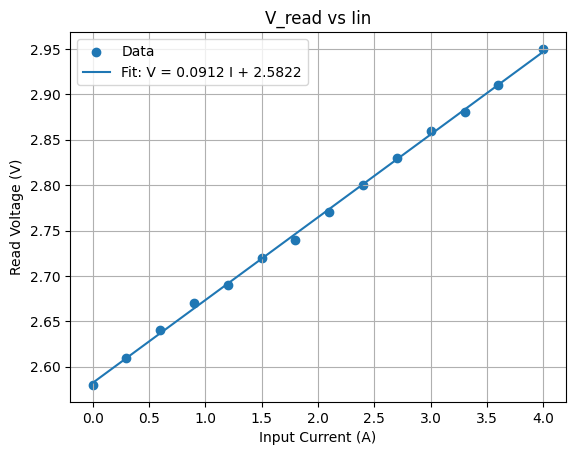

Sensitivity (dV/dI): 91.2 mV/A
Offset (V at I=0): 2.582158 V


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = pd.read_csv("50A_sensor.csv")

# Columns (as you defined)
Iin = pd.to_numeric(data["I"], errors="coerce")
Vread = pd.to_numeric(data["V_read"], errors="coerce")

# Remove NaNs just in case
mask = ~(Iin.isna() | Vread.isna())
Iin = Iin[mask]
Vread = Vread[mask]

# ---- Linear fit (V = mI + b) ----
m, b = np.polyfit(Iin, Vread, 1)

# Sensitivity is slope
sensitivity = m

# ---- Plot ----
plt.figure()
plt.scatter(Iin, Vread, label="Data")

# Fit line
I_fit = np.linspace(Iin.min(), Iin.max(), 100)
V_fit = m * I_fit + b
plt.plot(I_fit, V_fit, label=f"Fit: V = {m:.4f} I + {b:.4f}")

plt.xlabel("Input Current (A)")
plt.ylabel("Read Voltage (V)")
plt.title("V_read vs Iin")
plt.grid()
plt.legend()

plt.show()

# ---- Report ----
print(f"Sensitivity (dV/dI): {sensitivity*1000:.1f} mV/A")
print(f"Offset (V at I=0): {b:.6f} V")

Sensitivity: 0.091233 V/A
Offset: 2.582158 V
ADC LSB size: 0.806 mV

--- Performance Metrics ---
Max error: 0.0707 A
RMS error: 0.0354 A


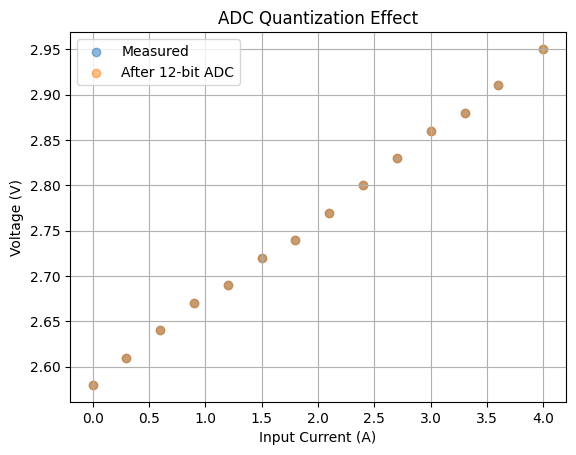

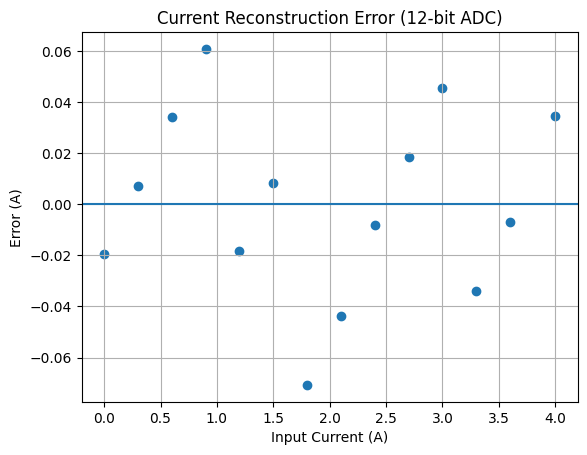

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load data ----
data = pd.read_csv("50A_sensor.csv")

Iin = pd.to_numeric(data["I"], errors="coerce")
Vread = pd.to_numeric(data["V_read"], errors="coerce")

mask = ~(Iin.isna() | Vread.isna())
Iin = Iin[mask]
Vread = Vread[mask]

# ---- Fit sensor model V = mI + b ----
m, b = np.polyfit(Iin, Vread, 1)

print(f"Sensitivity: {m:.6f} V/A")
print(f"Offset: {b:.6f} V")

# ---- ADC parameters (adjust to your TI ADC) ----
Vref = 3.3          # typical MCU ADC reference
N_bits = 12
ADC_levels = 2**N_bits

LSB = Vref / ADC_levels
print(f"ADC LSB size: {LSB*1000:.3f} mV")

# ---- Simulate ADC quantization ----
# Clip to ADC range
V_clipped = np.clip(Vread, 0, Vref)

# Convert to ADC codes
ADC_code = np.round(V_clipped / Vref * (ADC_levels - 1))

# Convert back to voltage (what ADC "sees")
V_quantized = ADC_code / (ADC_levels - 1) * Vref

# ---- Reconstruct current from quantized voltage ----
I_reconstructed = (V_quantized - b) / m

# ---- Error analysis ----
error = I_reconstructed - Iin

print("\n--- Performance Metrics ---")
print(f"Max error: {np.max(np.abs(error)):.4f} A")
print(f"RMS error: {np.sqrt(np.mean(error**2)):.4f} A")

# ---- Plot 1: Transfer curve ----
plt.figure()
plt.scatter(Iin, Vread, label="Measured", alpha=0.5)
plt.scatter(Iin, V_quantized, label="After 12-bit ADC", alpha=0.5)

plt.xlabel("Input Current (A)")
plt.ylabel("Voltage (V)")
plt.title("ADC Quantization Effect")
plt.legend()
plt.grid()

# ---- Plot 2: Current error ----
plt.figure()
plt.scatter(Iin, error)
plt.axhline(0)

plt.xlabel("Input Current (A)")
plt.ylabel("Error (A)")
plt.title("Current Reconstruction Error (12-bit ADC)")
plt.grid()

plt.show()

---- Sensor + ADC Quick Check ----
Sensitivity: 0.09123 V/A (91.23 mV/A)
Offset: 2.58216 V
ADC LSB: 0.806 mV
Current resolution: 0.00883 A
Quantization error: ±0.00442 A


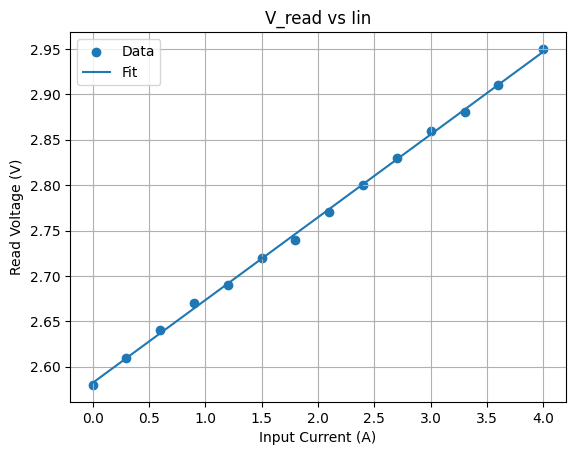

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("50A_sensor.csv")

Iin = pd.to_numeric(data["I"], errors="coerce")
Vread = pd.to_numeric(data["V_read"], errors="coerce")

mask = ~(Iin.isna() | Vread.isna())
Iin = Iin[mask]
Vread = Vread[mask]

# ---- Fit line ----
m, b = np.polyfit(Iin, Vread, 1)

# ---- ADC assumptions ----
Vref = 3.3
N_bits = 12
LSB = Vref / (2**N_bits)

# ---- Quick metrics ----
current_resolution = LSB / m          # A per LSB
quant_error = current_resolution / 2  # ± error

# ---- Print results ----
print("---- Sensor + ADC Quick Check ----")
print(f"Sensitivity: {m:.5f} V/A ({m*1000:.2f} mV/A)")
print(f"Offset: {b:.5f} V")
print(f"ADC LSB: {LSB*1000:.3f} mV")
print(f"Current resolution: {current_resolution:.5f} A")
print(f"Quantization error: ±{quant_error:.5f} A")

# ---- Simple plot ----
plt.figure()
plt.scatter(Iin, Vread, label="Data")
plt.plot(Iin, m*Iin + b, label="Fit")

plt.xlabel("Input Current (A)")
plt.ylabel("Read Voltage (V)")
plt.title("V_read vs Iin")
plt.legend()
plt.grid()
plt.show()